In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv(r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\data\processed\NSL_KDD_Test_Clean.csv')

print("Shape:", df.shape)
df.head()

Shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [3]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class',
       'difficulty_level'],
      dtype='object')

In [4]:
y = df.iloc[:, -2].astype(str).apply(lambda x: 0 if 'normal' in x.lower() else 1)
X = df.iloc[:, :-2]

print("X shape:", X.shape)
print("y unique:", y.unique())

X shape: (22544, 40)
y unique: [1 0]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (18035, 40)
Test shape: (4509, 40)


In [6]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 class
1    0.569227
0    0.430773
Name: proportion, dtype: float64

Test distribution:
 class
1    0.569306
0    0.430694
Name: proportion, dtype: float64


In [7]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 3
Numerical: 37


In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed shape:", X_train_processed.shape)

Processed shape: (18035, 115)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [11]:
y_pred = model.predict(X_test_processed)

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9873586161011311

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509


Confusion Matrix:

[[1917   25]
 [  32 2535]]


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_processed, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [14]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Accuracy: 0.9875803947660236

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



In [15]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best))

Precision: 0.9902381882077314
Recall: 0.987923646279704
F1 Score: 0.9890795631825273
ROC-AUC: 0.9875251599060723


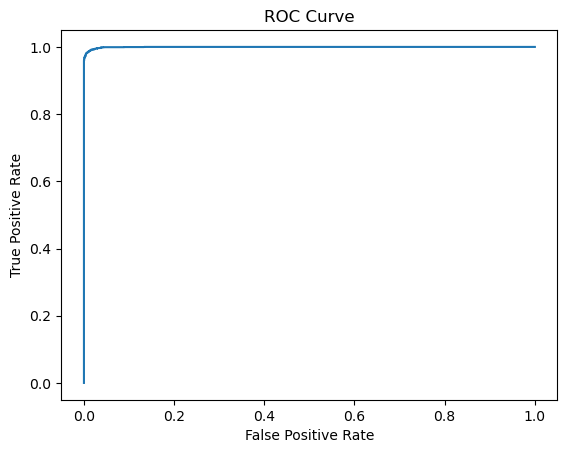

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

y_prob = best_model.predict_proba(X_test_processed)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [17]:
import pandas as pd

importances = best_model.feature_importances_

# get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
2,num__dst_bytes,0.114467
1,num__src_bytes,0.114421
62,cat__service_http,0.071688
35,num__dst_host_rerror_rate,0.060722
28,num__dst_host_srv_count,0.058117
30,num__dst_host_diff_srv_rate,0.041694
29,num__dst_host_same_srv_rate,0.041528
36,num__dst_host_srv_rerror_rate,0.034896
113,cat__flag_SF,0.034356
0,num__duration,0.032862


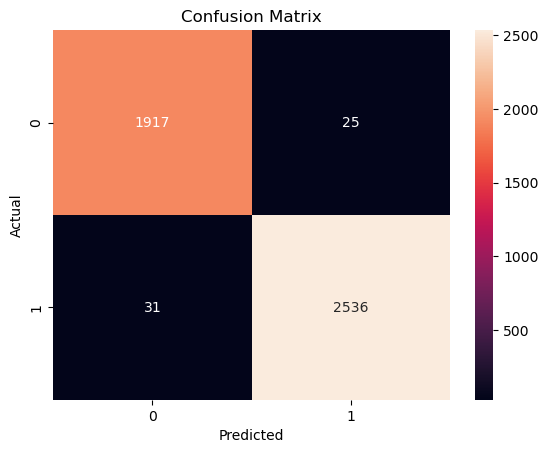

In [18]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("Train Accuracy:", best_model.score(X_train_processed, y_train))
print("Test Accuracy:", best_model.score(X_test_processed, y_test))

Train Accuracy: 0.996617687829221
Test Accuracy: 0.9875803947660236


In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.9864153  0.98835597 0.98613806 0.98946493 0.99029665]
Mean CV Accuracy: 0.988134183532021


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

C:\Users\ruchi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9860279441117764
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



In [22]:
print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_best))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

RandomForest Accuracy: 0.9875803947660236
XGBoost Accuracy: 0.9860279441117764


In [23]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_processed, y_train)

y_pred_svm = svm_model.predict(X_test_processed)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9691727655799512
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1942
           1       0.96      0.98      0.97      2567

    accuracy                           0.97      4509
   macro avg       0.97      0.97      0.97      4509
weighted avg       0.97      0.97      0.97      4509



In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_test_processed)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

C:\Users\ruchi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ruchi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ruchi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ruchi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

KNN Accuracy: 0.977156797516079
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1942
           1       0.98      0.98      0.98      2567

    accuracy                           0.98      4509
   macro avg       0.98      0.98      0.98      4509
weighted avg       0.98      0.98      0.98      4509



In [26]:
from sklearn.naive_bayes import GaussianNB

X_train_dense = X_train_processed
X_test_dense = X_test_processed

nb_model = GaussianNB()

nb_model.fit(X_train_dense, y_train)

y_pred_nb = nb_model.predict(X_test_dense)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7786648924373475
              precision    recall  f1-score   support

           0       0.66      0.99      0.79      1942
           1       0.99      0.62      0.76      2567

    accuracy                           0.78      4509
   macro avg       0.83      0.80      0.78      4509
weighted avg       0.85      0.78      0.77      4509



In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,   # fast + effective
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_processed, y_train)

print("Best Params:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}


In [28]:
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9884675094255932
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

In [30]:
import pandas as pd

importances = best_rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_features = feat_imp.head(20)["feature"].tolist()
print(top_features)

['num__src_bytes', 'num__dst_bytes', 'cat__service_http', 'num__dst_host_srv_count', 'num__dst_host_rerror_rate', 'num__dst_host_diff_srv_rate', 'num__dst_host_same_srv_rate', 'cat__flag_SF', 'num__dst_host_srv_rerror_rate', 'num__logged_in', 'num__duration', 'num__dst_host_same_src_port_rate', 'num__srv_count', 'num__count', 'num__same_srv_rate', 'num__dst_host_count', 'num__dst_host_srv_diff_host_rate', 'cat__service_domain_u', 'num__diff_srv_rate', 'num__srv_rerror_rate']


In [31]:
rf1 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2 = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)

rf1.fit(X_train_processed, y_train)
rf2.fit(X_train_processed, y_train)

pred1 = rf1.predict(X_test_processed)
pred2 = rf2.predict(X_test_processed)

# majority voting
final_pred = (pred1 + pred2) >= 1

In [32]:
print("Best Params:", random_search.best_params_)

Best Params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}


In [33]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,   # 👈 important (progress दिखेगा)
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_processed, y_train)

print("✅ Best Params:", random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


In [34]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train_processed, y_train)

y_pred_final = best_rf.predict(X_test_processed)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Final Accuracy: 0.9882457307607008
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1942
           1       0.99      0.99      0.99      2567

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



In [35]:
import joblib
import os

os.makedirs("ml_model", exist_ok=True)

joblib.dump(best_rf, "ml_model/model.pkl")
joblib.dump(preprocessor, "ml_model/scaler.pkl")

print("🔥 Final optimized model saved!")

🔥 Final optimized model saved!


In [36]:
print("Train Accuracy:", best_rf.score(X_train_processed, y_train))
print("Test Accuracy:", best_rf.score(X_test_processed, y_test))

Train Accuracy: 0.9965622400887164
Test Accuracy: 0.9882457307607008
